Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

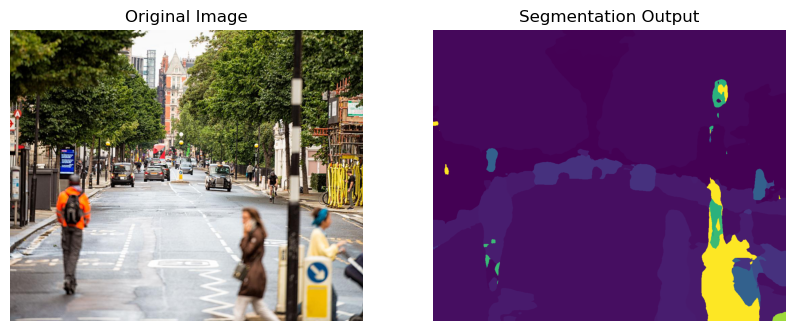

In [2]:
import torch
import matplotlib.pyplot as plt
from PIL import Image
from transformers import AutoImageProcessor, SegformerForSemanticSegmentation

# Load the pretrained model
model_name = "nvidia/segformer-b0-finetuned-ade-512-512"

processor = AutoImageProcessor.from_pretrained(model_name)
model = SegformerForSemanticSegmentation.from_pretrained(model_name)

# Load the image
image = Image.open("image1.jpeg").convert("RGB")

# Prepare the image for the model
inputs = processor(images=image, return_tensors="pt")

# Predict the segmentation
with torch.no_grad():
    output = model(**inputs)

# Get the segmentation result
segmentation = output.logits

segmentation = torch.nn.functional.interpolate(
    segmentation,
    size=image.size[::-1],
    mode="bilinear",
    align_corners=False
)

# Find the class for each pixel
segmentation_map = segmentation.argmax(dim=1)[0]

# Display the results
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(segmentation_map)
plt.title("Segmentation Output")
plt.axis("off")

plt.show()